In [ ]:
# 1. Import libraries
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 2. Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)
print("Dataset shape:", X.shape)

Dataset shape: (70000, 784)


In [ ]:
print(X[:5])

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
print(X[:10])

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# 4. Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 5. Simple Perceptron
perceptron = Perceptron(max_iter=1000,random_state=42)

In [ ]:
# Model training
perceptron.fit(X_train, y_train)
# Prediction
y_pred_perceptron = perceptron.predict(X_test)
# Accuracy
perceptron_accuracy = accuracy_score(y_test, y_pred_perceptron)
print("\nSimple Perceptron Accuracy:",perceptron_accuracy)


Simple Perceptron Accuracy: 0.881


In [ ]:
# 6. Multi-Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(100,),max_iter=20,random_state=42)
# Model training
mlp.fit(X_train, y_train)
# Prediction
y_pred_mlp = mlp.predict(X_test)
# Accuracy
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
print("MLP Accuracy:", mlp_accuracy)

MLP Accuracy: 0.9729285714285715


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# 7. Comparison
print("\nPerformance Comparison")
print("Perceptron Accuracy : {:.2f}%".format(perceptron_accuracy * 100))
print("MLP Accuracy : {:.2f}%".format(mlp_accuracy * 100))


Performance Comparison
Perceptron Accuracy : 88.10%
MLP Accuracy : 97.29%


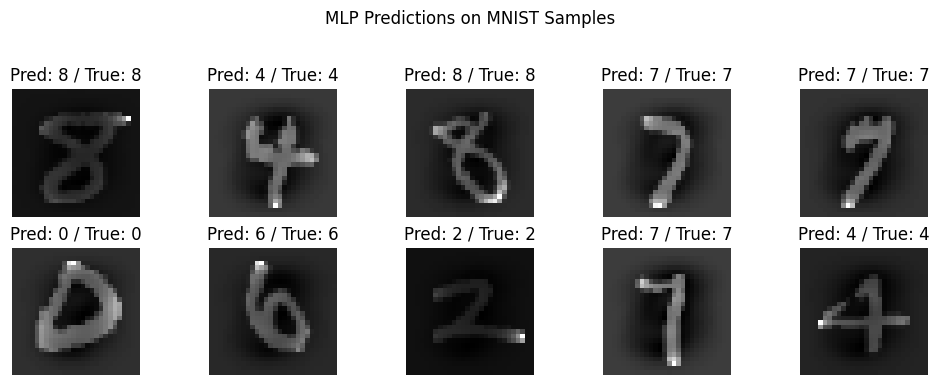

In [ ]:
import matplotlib.pyplot as plt

#8.Visualization
plt.figure(figsize=(10,4)) # Create the figure once
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred_mlp[i]} / True: {y_test[i]}")
    plt.axis('off')
plt.suptitle("MLP Predictions on MNIST Samples") # Set super title once
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()